In [1]:
import config
import torch
import sys
sys.path.append('../util')
sys.path.append('../others_networks')
from Trainer import Trainer
from util import show_dataset_prev
from GenericDatasetReader import get_datasets

from UNext import *

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
result_path = './UNext/'

/home/calculon/miniconda3/envs/pytorch/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [2]:
num_classes  = config.num_classes
in_channels  = config.in_channels
out_channels = 1

train_loader, test_loader, val_loader = get_datasets(dataset_dir=config.dataset_path, 
                                              resolution=config.dataset_resolution, 
                                              batch_size=config.batch_size)

torch.Size([16, 3, 224, 224]) torch.Size([16, 1, 224, 224])
8701 97 98


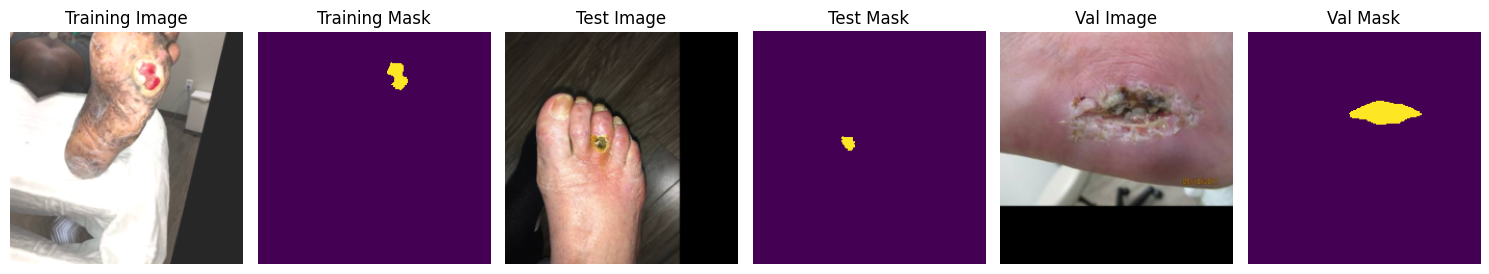

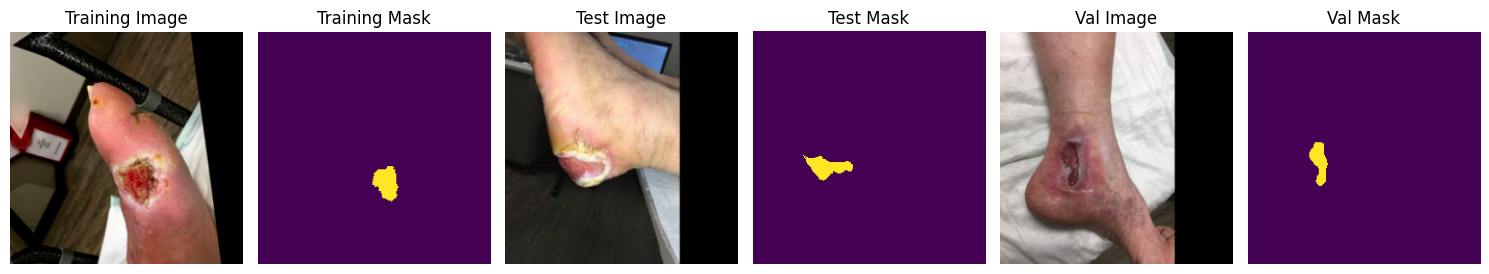

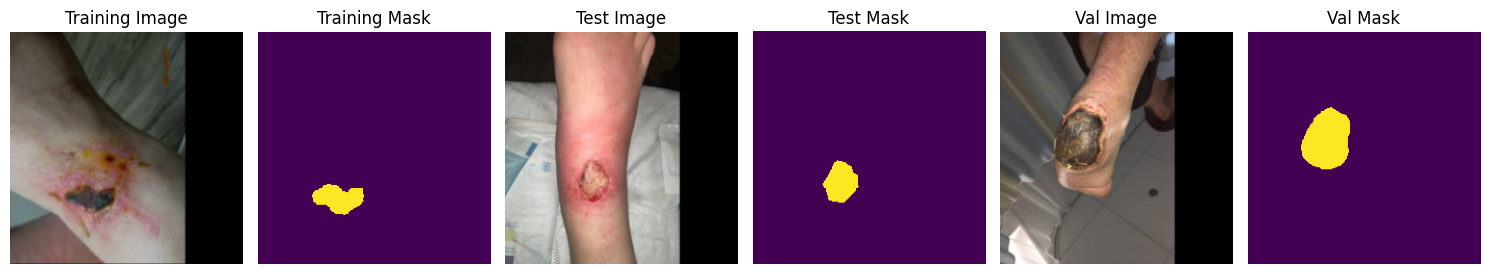

In [3]:
for (images_train, masks_train), (images_test, masks_test) in zip(train_loader, test_loader):
    print(images_train.shape, masks_train.shape)
    break

print(len(train_loader.dataset), len(test_loader.dataset), len(val_loader.dataset))

show_dataset_prev(train_loader, test_loader, val_loader, num_images=3)

In [4]:
def train(model, model_name=None, epochs=300, re_evaluate=True):
    model_filename = f'{model_name}-epochs{epochs}.pth'

    
    trainer = Trainer(num_classes=num_classes,
                    model_filename=model_filename, 
                    model_dir=result_path, 
                    save_xlsx=True)
    model = trainer.train(model, train_loader, val_loader, test_loader,
                            num_epochs=epochs, 
                            verbose=1, 
                            save_every=5, 
                            learning_rate=1e-3,
                            continue_from_last=True,
                            # we are re-evaluating after loading the model 
                            # because we refactored the code and want to see the new results
                            re_evaluate=re_evaluate)
    model.to(device)
    return trainer.get_best_test_stats()



In [5]:
model = UNext(input_channels=in_channels, num_classes=out_channels, img_size=config.dataset_resolution)
stats1 = train(model,'UNext-1')

Device: cuda
Trainable_parameters: 1471921
Loss function: Losses.BCEDiceLoss
Reevaluate is on
Trained model already exists. 
Loading latest version.
Loaded model: ./UNext//UNext-1-epochs300.pth
Evaluating the latest version...
Loss: 0.0000 F1: 0.9444 mIoU: 0.9001 Prec: 0.9422 Recall: 0.9469 Q: 0.8504
Loading best version.
Loaded model: ./UNext//UNext-1-epochs300-best.pth
Evaluating the best version...
Loss: 0.0000 F1: 0.9445 mIoU: 0.9006 Prec: 0.9372 Recall: 0.9523 Q: 0.8510
Best version has the best f1-score on [testset]: best(0.9445) latest(0.9444)
Best version loaded.


In [6]:
model = UNext(input_channels=in_channels, num_classes=out_channels, img_size=config.dataset_resolution)
stats2 = train(model,'UNext-2')

Device: cuda
Trainable_parameters: 1471921
Loss function: Losses.BCEDiceLoss
Reevaluate is on
Trained model already exists. 
Loading latest version.
Loaded model: ./UNext//UNext-2-epochs300.pth
Evaluating the latest version...
Loss: 0.0000 F1: 0.9364 mIoU: 0.8871 Prec: 0.9475 Recall: 0.9261 Q: 0.8309
Loading best version.
Loaded model: ./UNext//UNext-2-epochs300-best.pth
Evaluating the best version...
Loss: 0.0000 F1: 0.9429 mIoU: 0.8976 Prec: 0.9420 Recall: 0.9447 Q: 0.8466
Best version has the best f1-score on [testset]: best(0.9429) latest(0.9364)
Best version loaded.


In [7]:
model = UNext(input_channels=in_channels, num_classes=out_channels, img_size=config.dataset_resolution)
stats3 = train(model,'UNext-3')

Device: cuda
Trainable_parameters: 1471921
Loss function: Losses.BCEDiceLoss
Reevaluate is on
Trained model already exists. 
Loading latest version.
Loaded model: ./UNext//UNext-3-epochs300.pth
Evaluating the latest version...
Loss: 0.0000 F1: 0.9405 mIoU: 0.8939 Prec: 0.9471 Recall: 0.9349 Q: 0.8410
Loading best version.
Loaded model: ./UNext//UNext-3-epochs300-best.pth
Evaluating the best version...
Loss: 0.0000 F1: 0.9372 mIoU: 0.8890 Prec: 0.9411 Recall: 0.9358 Q: 0.8337
Latest version has the best f1-score on [testset]: latest(0.9405) best(0.9372)
Loaded model: ./UNext//UNext-3-epochs300.pth
Latest version loaded.


In [8]:
print("AVG F1-Score:", round((stats1['f1']+stats2['f1']+stats3['f1'])/3.0,3) )
print("Max F1-Score:", round(max(stats1['f1'],stats2['f1'],stats3['f1']),3) )

print("AVG mIoU:", round((stats1['miou']+stats2['miou']+stats3['miou'])/3.0,3) )
print("AVG mIoU:", round(max(stats1['miou'],stats2['miou'],stats3['miou']),3) )

AVG F1-Score: 0.943
Max F1-Score: 0.944
AVG mIoU: 0.897
AVG mIoU: 0.901
